In [74]:
import pandas as pd

In [75]:
BASE_DATA = "data/"
START_DATE = '2012-01-01'
# 1. Đọc dữ liệu
orders = pd.read_csv(BASE_DATA+'orders.csv', parse_dates=['order_date'])
payments = pd.read_csv(BASE_DATA+'payments.csv')
returns = pd.read_csv(BASE_DATA+'returns.csv')
geography = pd.read_csv(BASE_DATA+'geography.csv')
orders = orders[orders['order_date'] >= START_DATE]
order_items = pd.read_csv(BASE_DATA+'order_items.csv')
customers = pd.read_csv(BASE_DATA+'customers.csv')
valid_order_ids = orders['order_id'].unique()
payments = payments[payments['order_id'].isin(valid_order_ids)]
returns = returns[returns['order_id'].isin(valid_order_ids)]


/var/folders/yf/z8cyz0qn4r557bdjflrksgkw0000gn/T/ipykernel_45844/2292279803.py:9: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items = pd.read_csv(BASE_DATA+'order_items.csv')


In [76]:

# 1. Định nghĩa ngày tham chiếu (Ngày cuối cùng trong dữ liệu + 1 ngày)
ref_date = pd.to_datetime('2023-01-01')

# 2. Merge dữ liệu đơn hàng với giá trị thanh toán
rfm = orders.merge(payments[['order_id', 'payment_value']], on='order_id', how='left')

# 3. Lọc bỏ các đơn hàng đã bị hủy
rfm = rfm[rfm['order_status'] != 'cancelled']

# 4. Gom nhóm theo khách hàng và tính toán các chỉ số cơ bản
rfm_agg = rfm.groupby('customer_id').agg(
    last_order_date = ('order_date', 'max'),
    first_order_date = ('order_date', 'min'),
    frequency = ('order_id', 'nunique'),
    monetary = ('payment_value', 'sum'),
    avg_order_value = ('payment_value', 'mean')
).reset_index()

# 5. Tính toán số ngày Recency (độ mới) và Tenure (thâm niên)
rfm_agg['recency_days'] = (ref_date - rfm_agg['last_order_date']).dt.days
rfm_agg['tenure_days'] = (ref_date - rfm_agg['first_order_date']).dt.days

# 6. Tính điểm R, F, M (Scoring) theo phương pháp chia 5 phần bằng nhau (qcut)
# Điểm R: Ngày mua gần nhất càng nhỏ thì điểm càng cao (5 là tốt nhất)
rfm_agg['R_score'] = pd.qcut(rfm_agg['recency_days'], q=5, labels=[5, 4, 3, 2, 1]).astype(int)

# Điểm F: Tần suất mua càng cao điểm càng cao. Dùng rank(method='first') để xử lý dữ liệu trùng lặp
rfm_agg['F_score'] = pd.qcut(rfm_agg['frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5]).astype(int)

# Điểm M: Tổng giá trị mua hàng càng cao điểm càng cao
rfm_agg['M_score'] = pd.qcut(rfm_agg['monetary'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5]).astype(int)

# 7. Tạo điểm RFM tổng hợp (Ví dụ: tổ hợp 3 chữ số R-F-M)
rfm_agg['RFM_score'] = rfm_agg['R_score'] * 100 + rfm_agg['F_score'] * 10 + rfm_agg['M_score']

In [77]:
def rfm_segment(row):
    # 1. Trích xuất các giá trị điểm số từ hàng
    r, f, m = row['R_score'], row['F_score'], row['M_score']
    
    # 2. Phân loại theo điều kiện (Thứ tự ưu tiên từ cao xuống thấp)
    if r >= 4 and f >= 4:
        return 'Champions'
    
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'
    
    elif r >= 4 and f <= 2:
        return 'New Customers'
    
    elif r >= 3 and f >= 1:
        return 'Potential Loyalists'
    
    elif r <= 2 and f >= 4 and m >= 4:
        return 'Cant Lose Them'
    
    elif r <= 2 and f >= 3:
        return 'At Risk'
    
    elif r <= 2 and f <= 2:
        return 'Lost'
    
    elif r == 3 and f <= 2:
        return 'About To Sleep'
    
    else:
        return 'Need Attention'

# 3. Áp dụng hàm cho toàn bộ tập dữ liệu
rfm_agg['rfm_segment'] = rfm_agg.apply(rfm_segment, axis=1)

In [78]:
# 1. Merge thông tin khách hàng với dữ liệu RFM
dim_cust = customers.merge(rfm_agg, on='customer_id', how='left')

# 2. Merge thêm thông tin địa lý dựa trên mã zip (loại bỏ trùng lặp mã zip trước khi merge)
dim_cust = dim_cust.merge(
    geography[['zip', 'region']].drop_duplicates(subset='zip'),
    on='zip', 
    how='left'
)

# 3. Xử lý các giá trị thiếu (NaN) cho những khách hàng chưa từng mua hàng
dim_cust['frequency'] = dim_cust['frequency'].fillna(0).astype(int)
dim_cust['monetary'] = dim_cust['monetary'].fillna(0)
dim_cust['rfm_segment'] = dim_cust['rfm_segment'].fillna('Never Purchased')

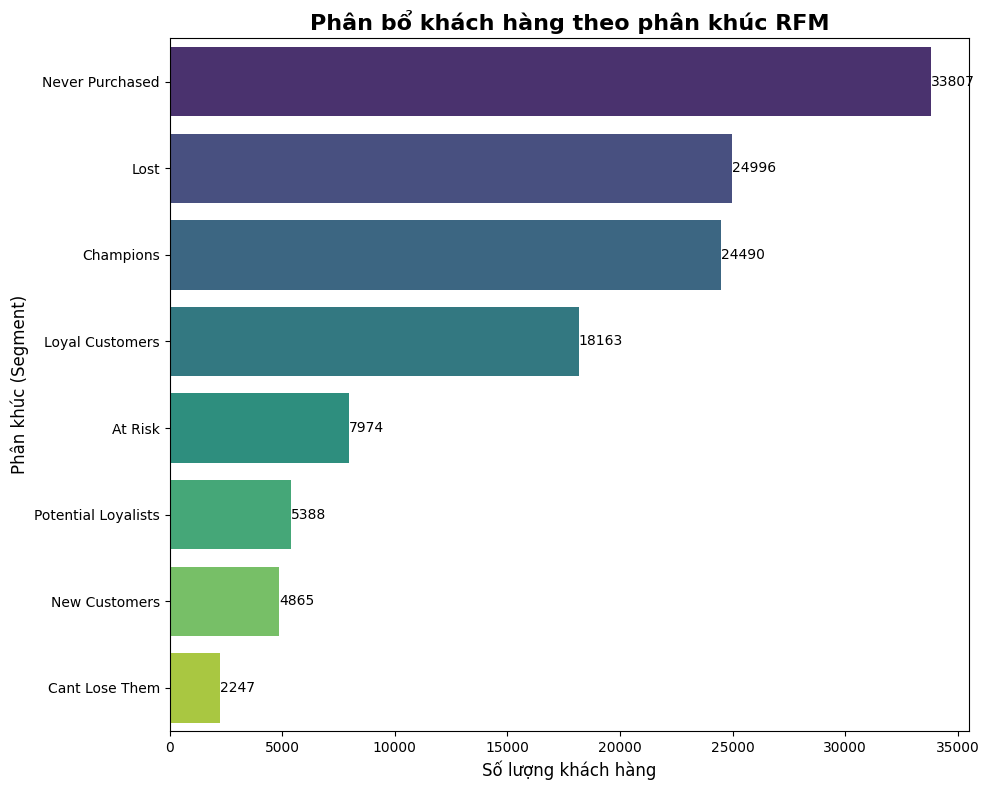

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Tính toán số lượng khách hàng trong mỗi phân khúc và sắp xếp giảm dần
segment_counts = dim_cust['rfm_segment'].value_counts().reset_index()
segment_counts.columns = ['rfm_segment', 'count']

# 2. Vẽ biểu đồ thanh ngang
plt.figure(figsize=(10, 8)) # Thiết lập kích thước khung hình

sns.barplot(
    data=segment_counts, 
    y='rfm_segment', 
    x='count', 
    palette='viridis', 
    hue='rfm_segment',
    legend=False
)

# 3. Thêm tiêu đề và nhãn
plt.title('Phân bổ khách hàng theo phân khúc RFM', fontsize=16, fontweight='bold')
plt.xlabel('Số lượng khách hàng', fontsize=12)
plt.ylabel('Phân khúc (Segment)', fontsize=12)

# 4. Hiển thị giá trị số lượng trên từng thanh (tùy chọn)
for i, count in enumerate(segment_counts['count']):
    plt.text(count + 0.5, i, str(int(count)), va='center', fontsize=10)

plt.tight_layout()
plt.show()

In [80]:
returns

,return_id,order_id,product_id,return_date,return_reason,return_quantity,refund_amount
0,RET-000001,2,609,2012-07-25,late_delivery,6,52458.01
1,RET-000002,32,1862,2012-07-16,wrong_size,2,5141.37
2,RET-000003,35,2359,2012-07-16,wrong_size,1,5315.95
3,RET-000004,47,1449,2012-07-11,wrong_size,4,6493.75
4,RET-000005,47,1450,2012-07-25,wrong_size,1,1740.76
...,...,...,...,...,...,...,...
39934,RET-051470,832867,653,2022-12-27,wrong_size,3,24741.62
39935,RET-051471,832890,792,2022-12-30,late_delivery,1,560.50
39936,RET-051481,833005,449,2022-12-31,defective,1,10002.55
39937,RET-051494,833234,1085,2022-12-28,wrong_size,1,815.57


In [83]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Giả sử đã có 2 DataFrame: returns và order_items
# Kết hợp 2 bảng dựa trên order_id và product_id
df_merged = returns.merge(order_items[['order_id', 'product_id', 'unit_price', 'quantity']], 
                          on=['order_id', 'product_id'], 
                          how='left')

# 2. Tính giá trị gốc của lượng hàng bị trả (Original Value)
# Lưu ý: quantity ở đây nên là return_quantity từ bảng returns
df_merged['original_value'] = df_merged['unit_price'] * df_merged['return_quantity']

# 3. Gom nhóm theo lý do trả hàng (Lỗi doanh nghiệp)
analysis = df_merged.groupby('return_reason').agg({
    'original_value': 'sum',
    'refund_amount': 'sum'
}).reset_index()

# Tính tỷ lệ thất thoát của khách hàng (%)
analysis['loss_percentage'] = ((analysis['original_value'] - analysis['refund_amount']) / analysis['original_value'] * 100).round(2)

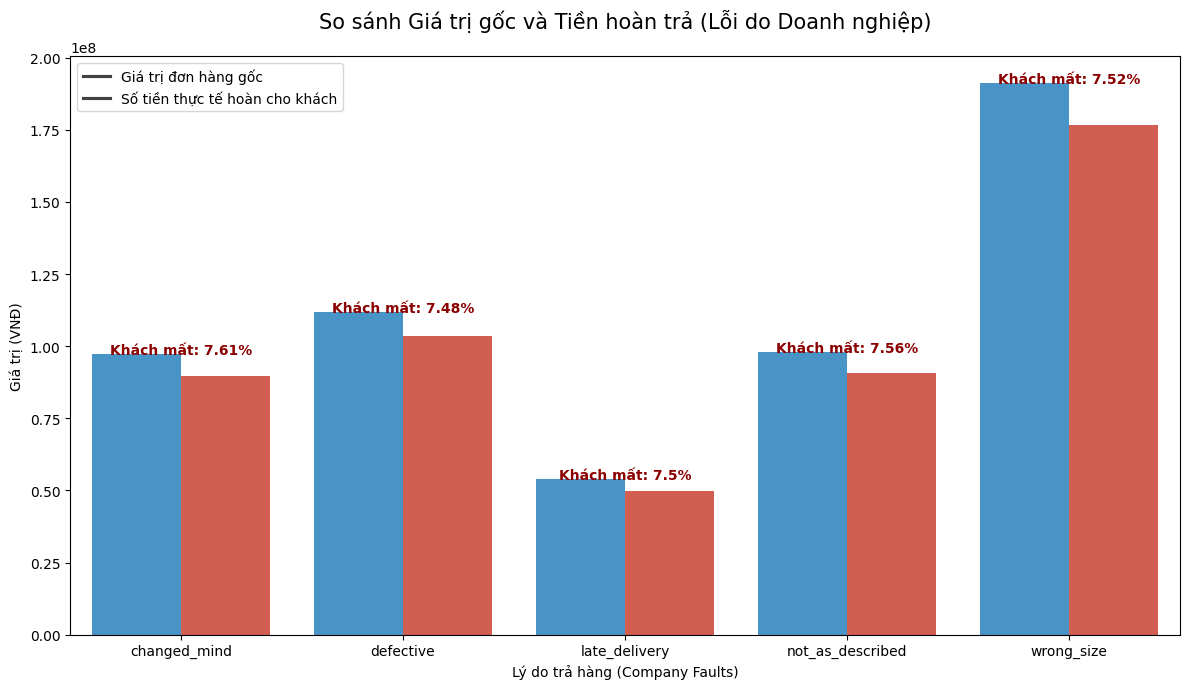

In [84]:
# Chuyển dữ liệu sang dạng long-format để vẽ với Seaborn
plot_data = analysis.melt(id_vars='return_reason', 
                          value_vars=['original_value', 'refund_amount'],
                          var_name='Type', value_name='Amount')

plt.figure(figsize=(12, 7))

# Vẽ biểu đồ cột đôi
sns.barplot(data=plot_data, x='return_reason', y='Amount', hue='Type', palette=['#3498db', '#e74c3c'])

# Thêm nhãn tỷ lệ % không được hoàn lên đầu cột
for i, reason in enumerate(analysis['return_reason']):
    loss = analysis.loc[i, 'loss_percentage']
    plt.text(i, analysis.loc[i, 'original_value'] + 5, f'Khách mất: {loss}%', 
             ha='center', color='darkred', fontweight='bold')

plt.title('So sánh Giá trị gốc và Tiền hoàn trả (Lỗi do Doanh nghiệp)', fontsize=15, pad=20)
plt.ylabel('Giá trị (VNĐ)')
plt.xlabel('Lý do trả hàng (Company Faults)')
plt.legend(['Giá trị đơn hàng gốc', 'Số tiền thực tế hoàn cho khách'])

plt.tight_layout()
plt.show()